# Backtest 005d-HMM — TTM Breakout (v1/v2/v3 best params) + 2-State HMM Position Sizing

**Strategy:** Each of the three optimised TTM entry versions paired with a walk-forward
2-state HMM (Risk-On / Risk-Off, weekly retraining) as a position-sizing overlay.

| Regime   | Budget fraction |
|----------|-----------------|
| Risk-On  | 100%            |
| Risk-Off | 25%             |

Best params loaded live from `backend/assets/ttm_best_params_005d.json`.


## 1. Imports

In [80]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

import vectorbt as vbt
import numba as nb

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.vwap import avwap_func_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator

plt.style.use('dark_background')
print('imports ok')


imports ok


## 2. Load Data

In [81]:
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'

df_raw = load_stocks()

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
else:
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)
    print(f'BENCHMARK {BENCHMARK!r} not found — using equal-weight index')

print(f'Symbols  : {len(valid_syms)}')
print(f'Benchmark: {BENCHMARK}  rows={len(bm_close)}')


Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2501, 990)  |  2016-06-20 → 2026-06-19
Symbols  : 198
Benchmark: VNINDEX  rows=2501


## 3. TTM Strategy Helpers

In [82]:
# ── copied from backend/app/services/strategies/breakout_ttm.py ───────────────
from backend.app.services.indicators.kama import kama_2d, slope_flat_2d

from backend.app.services.indicators.common import shift_2d, count_consecutive_neg_2d


@nb.njit
def _early_exit_nb(close_2d, low_2d, entries_2d, window, pct):
    """
    For each symbol: after an entry, if the bar LOW drops > pct from entry close
    within the first  bars, emit an exit signal.
    Uses low (not close) so intraday wicks are captured as true MAE.
    """
    n_rows, n_cols = close_2d.shape
    out = np.zeros((n_rows, n_cols), dtype=np.bool_)
    for col in range(n_cols):
        entry_bar   = -1
        entry_close = np.nan
        for row in range(n_rows):
            if entries_2d[row, col]:
                entry_bar   = row
                entry_close = close_2d[row, col]
            if entry_bar >= 0:
                bars_since = row - entry_bar
                if 1 <= bars_since <= window:
                    mae = (entry_close - low_2d[row, col]) / entry_close
                    if mae > pct:
                        out[row, col] = True
                        entry_bar = -1   # stop watching after firing
    return out


def early_exit_signal(close, low, entries, window=5, pct=0.05):
    """Returns a boolean exit DataFrame: fires when MAE (low-based) > pct within  bars of entry."""
    result = _early_exit_nb(
        close.to_numpy().astype(np.float64),
        low.to_numpy().astype(np.float64),
        entries.to_numpy().astype(np.bool_),
        window, pct,
    )
    return pd.DataFrame(result, index=close.index, columns=close.columns)


@nb.njit
def _max_hold_exit_nb(entries_2d, max_hold_days):
    """Exit when bars held since last entry exceed max_hold_days."""
    n_rows, n_cols = entries_2d.shape
    out = np.zeros((n_rows, n_cols), dtype=np.bool_)
    for col in range(n_cols):
        entry_bar = -1
        for row in range(n_rows):
            if entries_2d[row, col]:
                entry_bar = row
            if entry_bar >= 0:
                if row - entry_bar > max_hold_days:
                    out[row, col] = True
                    entry_bar = -1
    return out


def max_hold_exit_signal(entries, max_hold_days=160):
    """Exit when position held longer than max_hold_days (daily bars)."""
    result = _max_hold_exit_nb(entries.to_numpy().astype(np.bool_), max_hold_days)
    return pd.DataFrame(result, index=entries.index, columns=entries.columns)


print('early_exit_signal defined (MAE = low-based)')
print('max_hold_exit_signal defined (>30d default)')

print('Numba helpers compiled')


early_exit_signal defined (MAE = low-based)
max_hold_exit_signal defined (>30d default)
Numba helpers compiled


In [83]:
AVWAP = vbt.IndicatorFactory(
    class_name='AVWAP',
    short_name='avwap',
    input_names=['close', 'high', 'low', 'volume'],
    param_names=['is_highest', 'window'],
    output_names=['avwap'],
).from_apply_func(avwap_func_nb)

_avwap_lowest_cache = {}


def get_avwap_lowest(close, high, low, volume, window: int = 200):
    key = (id(close), id(high), id(low), id(volume), int(window))
    if key not in _avwap_lowest_cache:
        avwap = AVWAP.run(
            close, high, low, volume,
            is_highest=[False],
            window=int(window),
        ).avwap
        avwap_lowest = avwap.xs(False, level='avwap_is_highest', axis=1)
        avwap_lowest.columns = avwap_lowest.columns.get_level_values(-1)
        _avwap_lowest_cache[key] = avwap_lowest.reindex(columns=close.columns)
    return _avwap_lowest_cache[key]


def compute_signals(
    close, high, low, volume,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix
    william_vix_period:       int   = 20,
    # AVWAP filter
    # use_avwap_filter:         bool  = True,
    # avwap_window:             int   = 200,
    # KAMA slope filter (breakout entries only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
    # Near-recent-low filter: close must be within max_pct of rolling min close
    use_near_low_filter:      bool  = True,
    near_low_window:          int   = 5,
    near_low_max_pct:         float = 10.0,
):
    """
    Compute TTM Breakout entry signals.

    KAMA slope gate applies only to breakout-type entries:
      v1, v2    : full signal gated by flat KAMA slope
      v3 entry_1: squeeze-release breakout - gated by flat KAMA slope
      v3 entry_2: bottom-fishing (extended neg momentum) - NOT gated
      v3 WVF    : volatility spike / contrarian - NOT gated

    Near-low filter (optional): at entry, (close - MIN(close, N)) / MIN(close, N)
      must be < near_low_max_pct — avoids buying too far above recent lows.

    AVWAP gate applies after the TTM logic:
      final entry must also satisfy close > AVWAP(lowest).shift(1)
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    MIN  = vbt.IndicatorFactory.from_talib('MIN')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    # indicators -> numpy
    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MIN.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    # if use_avwap_filter:
    #     avwap_lowest = get_avwap_lowest(close, high, low, volume, avwap_window)
    #     avwap_prev_np = shift_2d(avwap_lowest.to_numpy(dtype=np.float64), 1)
    #     avwap_filter_np = (close_np > avwap_prev_np) & (~np.isnan(avwap_prev_np))
    # else:
    #     avwap_filter_np = np.ones_like(close_np, dtype=np.bool_)

    # sma200 = SMA.run(close, timeperiod=200).real.to_numpy()

    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)

    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np

    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1  < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2  < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3  < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np

    else:
        _, _, _, wvf_signal = williams_vix_fix_indicator(
            close, high, low,
            period=william_vix_period,
            mult=bb_multiplier,
            bbl=bb_window,
            lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
        )
        wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()
        entries_np =  wvf_np

    # entries_np = entries_np # & avwap_filter_np

    if use_near_low_filter:
        min_close_np = MIN.run(close, timeperiod=near_low_window).real.to_numpy()
        pct_above_low = (close_np - min_close_np) / min_close_np * 100.0
        near_low_np = (
            np.isfinite(pct_above_low)
            & (min_close_np > 0)
            & (pct_above_low < near_low_max_pct)
        )
        entries_np = entries_np & near_low_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=5, entries=None, max_hold_days=30):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings; if ``entries`` is given, also exits
                when hold time exceeds ``max_hold_days`` (default 30 daily bars).
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                where lowest_low = MIN(low, low_stop_lookback).
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop is placed at the swing low of the last
                low_stop_lookback bars.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    if entries is not None and max_hold_days is not None:
        exits_df = exits_df | max_hold_exit_signal(entries, max_hold_days=max_hold_days)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return exits_df, sl_stop_df


print('Signal functions defined')


Signal functions defined


In [84]:
# ── Chandelier Exit (port of the Pine Script reference) ───────────────────────
# Pine logic:
#   atr         = ta.atr(length)                              # Wilder ATR
#   highestHigh = avg(highest(close, length), highest(high, length))
#   lowestLow   = avg(lowest (close, length), lowest (low,  length))
#   chandLong   = highestHigh - atr*mult
#   chandShort  = lowestLow   + atr*mult
#   dir         = close>chandShort ? 1 : close<chandLong ? -1 : dir[prev]
#   chandExit   = dir>0 ? chandLong : chandShort
# We exit a LONG when dir flips +1 -> -1 (close breaks below the long trail).

@nb.njit(cache=True)
def _chandelier_nb(close, high, low, atr, multiplier, length):
    n, m = close.shape
    chand     = np.full((n, m), np.nan)
    direction = np.zeros((n, m), dtype=np.int64)
    for col in range(m):
        d = 1
        for i in range(n):
            c = close[i, col]
            a = atr[i, col]
            if np.isnan(c) or np.isnan(a) or i < length - 1:
                direction[i, col] = d
                continue
            hc = -1e18; hh = -1e18; lc = 1e18; ll = 1e18
            for k in range(i - length + 1, i + 1):
                cc = close[k, col]; hk = high[k, col]; lk = low[k, col]
                if cc > hc: hc = cc
                if hk > hh: hh = hk
                if cc < lc: lc = cc
                if lk < ll: ll = lk
            highest_high = 0.5 * (hc + hh)
            lowest_low   = 0.5 * (lc + ll)
            chand_long  = highest_high - a * multiplier
            chand_short = lowest_low   + a * multiplier
            if c > chand_short:
                d = 1
            elif c < chand_long:
                d = -1
            direction[i, col] = d
            chand[i, col] = chand_long if d > 0 else chand_short
    return chand, direction


def compute_exits_chandelier(close, high, low, length=5, multiplier=2.2,
                             entries=None, max_hold_days=30, low_stop_lookback=5,
                             return_line=False):
    """
    Chandelier trailing-stop exits. Drop-in alternative to ``compute_exits``.

    Returns (exits_df, sl_stop_df) — same shape/contract as ``compute_exits`` so it
    can be swapped directly in ``vbt.Portfolio.from_signals``. The swing-low
    ``sl_stop_df`` (initial hard stop) is kept identical to ``compute_exits`` so an
    A/B test isolates ONLY the trailing mechanism.

    With return_line=True also returns (line_df, dir_df) for plotting/inspection.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=length
    ).real
    chand, direction = _chandelier_nb(
        close.to_numpy().astype(np.float64),
        high.to_numpy().astype(np.float64),
        low.to_numpy().astype(np.float64),
        atr_raw.to_numpy().astype(np.float64),
        float(multiplier), int(length),
    )
    dir_df  = pd.DataFrame(direction, index=close.index, columns=close.columns)
    line_df = pd.DataFrame(chand,     index=close.index, columns=close.columns)

    # Exit when the directional state flips long -> short.
    exits_df = (dir_df == -1) & (dir_df.shift(1) == 1)

    if entries is not None and max_hold_days is not None:
        exits_df = exits_df | max_hold_exit_signal(entries, max_hold_days=max_hold_days)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    if return_line:
        return exits_df, sl_stop_df, line_df, dir_df
    return exits_df, sl_stop_df


print('Chandelier exit defined (compute_exits_chandelier)')


Chandelier exit defined (compute_exits_chandelier)


## 4. Walk-Forward 2-State HMM Regime

In [85]:
# ── feature engineering on benchmark ─────────────────────────────────────────
W = 20

feat_bm = pd.DataFrame(index=bm_close.index)
feat_bm['log_ret']    = np.log(bm_close / bm_close.shift(1))
feat_bm['volatility'] = feat_bm['log_ret'].rolling(W).std()
feat_bm['momentum']   = np.log(bm_close / bm_close.shift(W))
feat_bm['vol_ratio']  = bm_volume / bm_volume.rolling(W).mean()
feat_bm = feat_bm.dropna()

FEATURE_COLS = ['log_ret', 'volatility', 'momentum', 'vol_ratio']
print(f'Feature matrix: {feat_bm.shape}')

Feature matrix: (2481, 4)


In [86]:
BURN_IN_DAYS = 252
RANDOM_SEED  = 42


In [87]:
def build_wf_regime(
    feat_df,
    feature_cols,
    n_components=2,
    burn_in=252,
    retrain_every=21,
    random_seed=42,
):
    """
    Walk-forward HMM regime labelling (zero lookahead).

    Returns a pd.Series of 'Bull' / 'Neutral' / 'Bear' (or 'Risk-On' / 'Risk-Off'
    for 2-state) indexed to feat_df, with NaN before the first prediction.
    """
    from hmmlearn.hmm import GaussianHMM
    from sklearn.preprocessing import StandardScaler

    feat_arr  = feat_df[feature_cols].values
    dates     = feat_df.index.tolist()
    n_total   = len(dates)
    wf_label  = pd.Series('Unknown', index=feat_df.index, name='regime')

    retrain_indices = list(range(burn_in - 1, n_total - 1, retrain_every))

    for ri, train_end_idx in enumerate(retrain_indices):
        X_train  = feat_arr[:train_end_idx + 1]
        scaler   = StandardScaler()
        X_scaled = scaler.fit_transform(X_train)

        model = GaussianHMM(
            n_components=n_components,
            covariance_type='full',
            n_iter=500,
            random_state=random_seed,
            tol=1e-4,
            verbose=False,
        )
        model.fit(X_scaled)
        states_train = model.predict(X_scaled)

        mean_rets = {
            s: feat_arr[:train_end_idx + 1, 0][states_train == s].mean()
            for s in range(n_components)
        }
        ranked    = sorted(mean_rets, key=mean_rets.get)
        if n_components == 2:
            label_map = {ranked[0]: 'Bear', ranked[1]: 'Bull'}
        else:
            label_map = {ranked[0]: 'Bear', ranked[1]: 'Neutral', ranked[2]: 'Bull'}

        current_label = label_map[states_train[-1]]
        next_idx      = retrain_indices[ri + 1] if ri + 1 < len(retrain_indices) else n_total
        wf_label.iloc[train_end_idx + 1:next_idx] = current_label

    return wf_label

print('build_wf_regime defined')


build_wf_regime defined


In [88]:
print('Running 2-state walk-forward HMM (weekly retraining) …')
regime_2state = build_wf_regime(
    feat_bm, FEATURE_COLS,
    n_components  = 2,
    burn_in       = BURN_IN_DAYS,
    retrain_every = 5,
    random_seed   = RANDOM_SEED,
)
regime_2state  = regime_2state.replace({'Bull': 'Risk-On', 'Neutral': 'Risk-On', 'Bear': 'Risk-Off'})
regime_aligned = regime_2state.reindex(close.index)
print('Done.')
print(regime_2state.value_counts().to_string())


Running 2-state walk-forward HMM (weekly retraining) …


Model is not converging.  Current: -3202.0188847110157 is not greater than -3202.018883822728. Delta is -8.88287559064338e-07
Model is not converging.  Current: -3248.6674028620932 is not greater than -3248.6674015959534. Delta is -1.2661398614000063e-06


Done.
regime
Risk-On     940
Risk-Off    844
Unknown     697


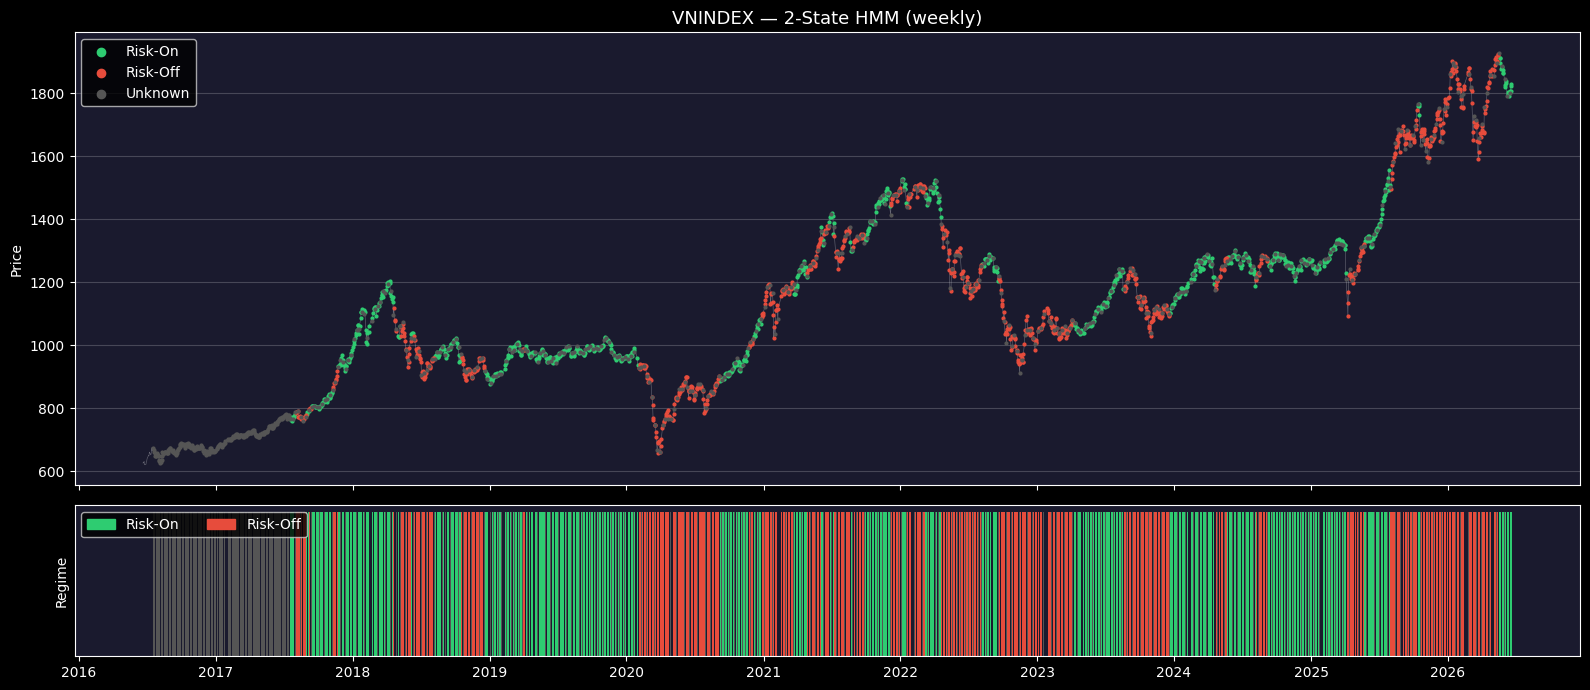

In [89]:
COLOR2 = {'Risk-On': '#2ecc71', 'Risk-Off': '#e74c3c', 'Unknown': '#555555'}

fig, axes = plt.subplots(2, 1, figsize=(16, 7),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax = axes[0]; ax.set_facecolor('#1a1a2e')
common = bm_close.index.intersection(regime_2state.index)
for lbl, col in COLOR2.items():
    mask = regime_2state.reindex(common) == lbl
    ax.scatter(common[mask], bm_close.reindex(common)[mask], s=4, c=col, label=lbl, zorder=3)
ax.plot(bm_close.index, bm_close.values, color='white', lw=0.4, alpha=0.35)
ax.set_ylabel('Price'); ax.set_title(f'{BENCHMARK} — 2-State HMM (weekly)', fontsize=13)
ax.legend(loc='upper left', markerscale=3); ax.yaxis.grid(True, alpha=0.2)

ax2 = axes[1]; ax2.set_facecolor('#1a1a2e')
c2 = [COLOR2.get(r, '#555') for r in regime_2state.reindex(common)]
ax2.bar(common, np.ones(len(common)), color=c2, width=1.5); ax2.set_yticks([])
ax2.set_ylabel('Regime')
patches2 = [mpatches.Patch(color=c, label=l) for l, c in COLOR2.items() if l != 'Unknown']
ax2.legend(handles=patches2, loc='upper left', ncol=2)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()


## 5. Load Best Params (all versions)

In [90]:
import json as _json
with open('../backend/assets/ttm_best_params_005d.json') as _f:
    ALL_BEST = _json.load(_f)

for ver, p in ALL_BEST.items():
    print(ver, p)
    # print(f"{ver}: bb_window={p['bb_window']}  kc_window={p['kc_window']}"
    #       f"  chand_length={p.get('chand_length','N/A')}  chand_mult={p.get('chand_mult','N/A')}")


v1 {'bb_window': 13, 'bb_multiplier': 1.9000000000000001, 'bb_matype': 1, 'kc_window': 20, 'kc_multiplier': 1.6, 'kc_atr_period': 18, 'chand_length': 32, 'chand_mult': 1.5, 'low_stop_lookback': 7, 'consecutive_neg_threshold': 10, 'william_vix_period': 20, 'kama_period': 6, 'kama_fast': 2, 'kama_slow': 39, 'kama_slope_win': 14, 'flat_threshold_pct': 1.3}
v2 {'bb_window': 20, 'bb_multiplier': 0.8, 'bb_matype': 3, 'kc_window': 22, 'kc_multiplier': 1.5, 'kc_atr_period': 13, 'chand_length': 11, 'chand_mult': 4.4, 'low_stop_lookback': 16, 'consecutive_neg_threshold': 6, 'william_vix_period': 24, 'kama_period': 7, 'kama_fast': 5, 'kama_slow': 49, 'kama_slope_win': 7, 'flat_threshold_pct': 1.3}
v3 {'bb_window': 15, 'bb_multiplier': 2.0, 'bb_matype': 0, 'kc_window': 47, 'kc_multiplier': 1.4000000000000001, 'kc_atr_period': 7, 'chand_length': 12, 'chand_mult': 2.5, 'low_stop_lookback': 3, 'consecutive_neg_threshold': 12, 'william_vix_period': 27, 'kama_period': 5, 'kama_fast': 2, 'kama_slow': 34

## 6. Run v1 / v2 / v3 — Baseline + HMM Position Sizing

In [91]:
def broadcast_mask(series_mask, columns):
    """Broadcast a boolean Series (dates,) to a DataFrame (dates × symbols)."""
    return pd.DataFrame(
        np.tile(series_mask.values.reshape(-1, 1), (1, len(columns))),
        index=series_mask.index, columns=columns,
    ).astype(bool)


In [92]:
# ── ATR-based volatility stop cap (for Risk-Off tightening) ───────────────────
ATR_PERIOD = 14
ATR_MULT   = 1.5   # Risk-Off stop = min(chandelier_sl, ATR_MULT * ATR / close)

_ATR = vbt.IndicatorFactory.from_talib('ATR')
atr_df       = _ATR.run(high, low, close, timeperiod=ATR_PERIOD).real
atr_stop_cap = (ATR_MULT * atr_df / close).clip(lower=0.01)
atr_stop_cap = atr_stop_cap.reindex(columns=valid_syms).ffill().bfill()

print(f'ATR stop cap  mean={atr_stop_cap.mean().mean():.4f}  '
      f'median={atr_stop_cap.median().median():.4f}')

# ── Relative Strength filter (20d stock return > 20d benchmark return) ─────────
RS_WINDOW = 20

stock_ret  = close / close.shift(RS_WINDOW) - 1
bm_ret     = bm_close / bm_close.shift(RS_WINDOW) - 1
bm_ret_2d  = pd.DataFrame(
    np.tile(bm_ret.values.reshape(-1, 1), (1, len(valid_syms))),
    index=bm_ret.index, columns=valid_syms,
)
rs_filter = (stock_ret > bm_ret_2d).fillna(False)

pass_rate = rs_filter.mean().mean()
print(f'RS filter     {rs_filter.sum().sum():,} / {rs_filter.size:,} bars pass ({pass_rate:.1%})')


ATR stop cap  mean=nan  median=nan
RS filter     223,973 / 495,198 bars pass (45.2%)


In [93]:
INIT_CASH = 100
SIZING    = {'Risk-On': 0.5, 'Risk-Off': 0.25, 'Unknown': 1.0}

portfolios = {}   # (ver, "base"|"hmm") → vbt.Portfolio

for ver in ['v1', 'v2', 'v3']:
    p = ALL_BEST[ver]
    print(f'\n── {ver} ──────────────────────────────────')

    # raw entries
    entries_raw = compute_signals(
        close, high, low, volume,
        bb_window                 = p['bb_window'],
        bb_multiplier             = p['bb_multiplier'],
        bb_matype                 = p['bb_matype'],
        kc_window                 = p['kc_window'],
        kc_multiplier             = p['kc_multiplier'],
        kc_atr_period             = p['kc_atr_period'],
        entry_version             = ver,
        consecutive_neg_threshold = p['consecutive_neg_threshold'],
        william_vix_period        = p['william_vix_period'],
        use_kama_slope            = True,
        kama_period               = p['kama_period'],
        kama_fast                 = p['kama_fast'],
        kama_slow                 = p['kama_slow'],
        kama_slope_win            = p['kama_slope_win'],
        flat_threshold_pct        = p['flat_threshold_pct'],
        use_near_low_filter       = False,
    )

    if 'chand_length' in p:
        exits, sl_stop = compute_exits_chandelier(
            close, high, low,
            length=p['chand_length'], multiplier=p['chand_mult'],
            entries=entries_raw, max_hold_days=30, low_stop_lookback=p['low_stop_lookback'],
        )
    else:
        exits, sl_stop = compute_exits(
            close, high, low,
            atr_multiplier=p['atr_multiplier'], atr_period=p['atr_period'],
            low_stop_lookback=p['low_stop_lookback'], entries=entries_raw,
        )

    # ── baseline: raw entries, chandelier stop ────────────────────────────────
    pf_b = vbt.Portfolio.from_signals(
        close=close, entries=entries_raw, exits=exits, sl_stop=sl_stop,
        freq='1d', group_by=False, cash_sharing=False, init_cash=INIT_CASH,
    )
    portfolios[(ver, 'base')] = pf_b

    # ── HMM combo ─────────────────────────────────────────────────────────────
    # [4] RS filter: only enter when stock outperforms benchmark over last 20d
    entries_hmm = entries_raw & rs_filter

    # [3] ATR-scaled stop: during Risk-Off replace chandelier with min(chandelier, 1.5*ATR/close)
    risk_off_mask = (regime_aligned == 'Risk-Off')
    risk_off_df   = broadcast_mask(risk_off_mask, valid_syms)

    _atr_cap    = atr_stop_cap.reindex_like(sl_stop).ffill().bfill()
    sl_stop_hmm = sl_stop.where(
        ~risk_off_df,
        np.minimum(sl_stop.values, _atr_cap.values),
    ).fillna(sl_stop)   # fallback: keep chandelier wherever cap is still NaN

    # position sizing 25% during Risk-Off
    size_frac    = regime_aligned.map(SIZING).fillna(1.0)
    size_frac_df = pd.DataFrame(
        np.tile(size_frac.values.reshape(-1, 1), (1, len(valid_syms))),
        index=size_frac.index, columns=valid_syms,
    )
    share_size_df = (size_frac_df * INIT_CASH / close).fillna(0).replace([np.inf, -np.inf], 0)

    pf_h = vbt.Portfolio.from_signals(
        close=close, entries=entries_hmm, exits=exits,
        sl_stop=sl_stop_hmm, size=share_size_df,
        freq='1d', group_by=False, cash_sharing=False, init_cash=INIT_CASH,
    )
    portfolios[(ver, 'hmm')] = pf_h

    n_base = int(entries_raw.sum().sum())
    n_hmm  = int(entries_hmm.sum().sum())
    s_b = pf_b.sharpe_ratio().mean()
    s_h = pf_h.sharpe_ratio().mean()
    dd_b = pf_b.max_drawdown().mean()
    dd_h = pf_h.max_drawdown().mean()
    print(f'  entries  base={n_base:,}  hmm={n_hmm:,}  (RS filtered {n_base-n_hmm:,})')
    print(f'  Baseline : Sharpe={s_b:.3f}  MaxDD={dd_b:.1%}')
    print(f'  HMM combo: Sharpe={s_h:.3f}  MaxDD={dd_h:.1%}  '
          f'(Sharpe {s_h-s_b:+.3f}  MaxDD {dd_h-dd_b:+.1%})')

print('\nAll done.')



── v1 ──────────────────────────────────
  entries  base=5,494  hmm=2,742  (RS filtered 2,752)
  Baseline : Sharpe=0.281  MaxDD=-27.6%
  HMM combo: Sharpe=inf  MaxDD=-17.2%  (Sharpe +inf  MaxDD +10.4%)

── v2 ──────────────────────────────────
  entries  base=12,669  hmm=4,792  (RS filtered 7,877)
  Baseline : Sharpe=0.379  MaxDD=-42.4%
  HMM combo: Sharpe=inf  MaxDD=-26.6%  (Sharpe +inf  MaxDD +15.7%)

── v3 ──────────────────────────────────
  entries  base=12,384  hmm=3,501  (RS filtered 8,883)
  Baseline : Sharpe=0.517  MaxDD=-44.4%
  HMM combo: Sharpe=inf  MaxDD=-21.7%  (Sharpe +inf  MaxDD +22.6%)

All done.


## 7. Results

In [94]:
def full_stats(pf, name):
    s = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return pd.Series({
        'Name':             name,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f"{(s > 0).sum()}/{len(s)}",
        'Sharpe > 1':       f"{(s > 1).sum()}/{len(s)}",
        'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).mean(), 3),
        'Calmar mean':      round(pf.calmar_ratio().replace([np.inf,-np.inf],np.nan).mean(), 3),
        'Total Ret mean':   f"{pf.total_return().replace([np.inf,-np.inf],np.nan).mean():.1%}",
        'Total Ret median': f"{pf.total_return().replace([np.inf,-np.inf],np.nan).median():.1%}",
        'Max DD mean':      f"{pf.max_drawdown().replace([np.inf,-np.inf],np.nan).mean():.1%}",
        'Max DD worst':     f"{pf.max_drawdown().replace([np.inf,-np.inf],np.nan).min():.1%}",
        'N Trades':         int(pf.trades.count().sum()),
        'Win Rate':         f"{pf.trades.win_rate().mean():.1%}",
        'Profit Factor':    round(pf.trades.profit_factor().replace([np.inf,-np.inf],np.nan).mean(), 3),
    })

rows = []
for ver in ['v1', 'v2', 'v3']:
    rows.append(full_stats(portfolios[(ver, 'base')], f'{ver} Baseline'))
    rows.append(full_stats(portfolios[(ver, 'hmm')],  f'{ver} HMM combo'))

display(pd.DataFrame(rows).set_index('Name').T)


Name,v1 Baseline,v1 HMM combo,v2 Baseline,v2 HMM combo,v3 Baseline,v3 HMM combo
Sharpe mean,0.281,0.163,0.379,0.244,0.517,0.277
Sharpe median,0.254,0.162,0.399,0.203,0.515,0.272
Sharpe > 0,146/198,124/196,160/198,137/197,178/198,145/197
Sharpe > 1,12/198,6/196,12/198,14/197,20/198,11/197
Sortino mean,0.494,0.35,0.61,0.466,0.809,0.516
Calmar mean,0.194,0.165,0.225,0.18,0.322,0.202
Total Ret mean,42.7%,15.2%,101.2%,23.7%,177.2%,23.6%
Total Ret median,18.2%,6.1%,55.9%,10.8%,94.9%,16.7%
Max DD mean,-27.6%,-17.2%,-42.4%,-26.6%,-44.4%,-21.7%
Max DD worst,-59.5%,-39.8%,-78.0%,-66.1%,-86.7%,-77.6%


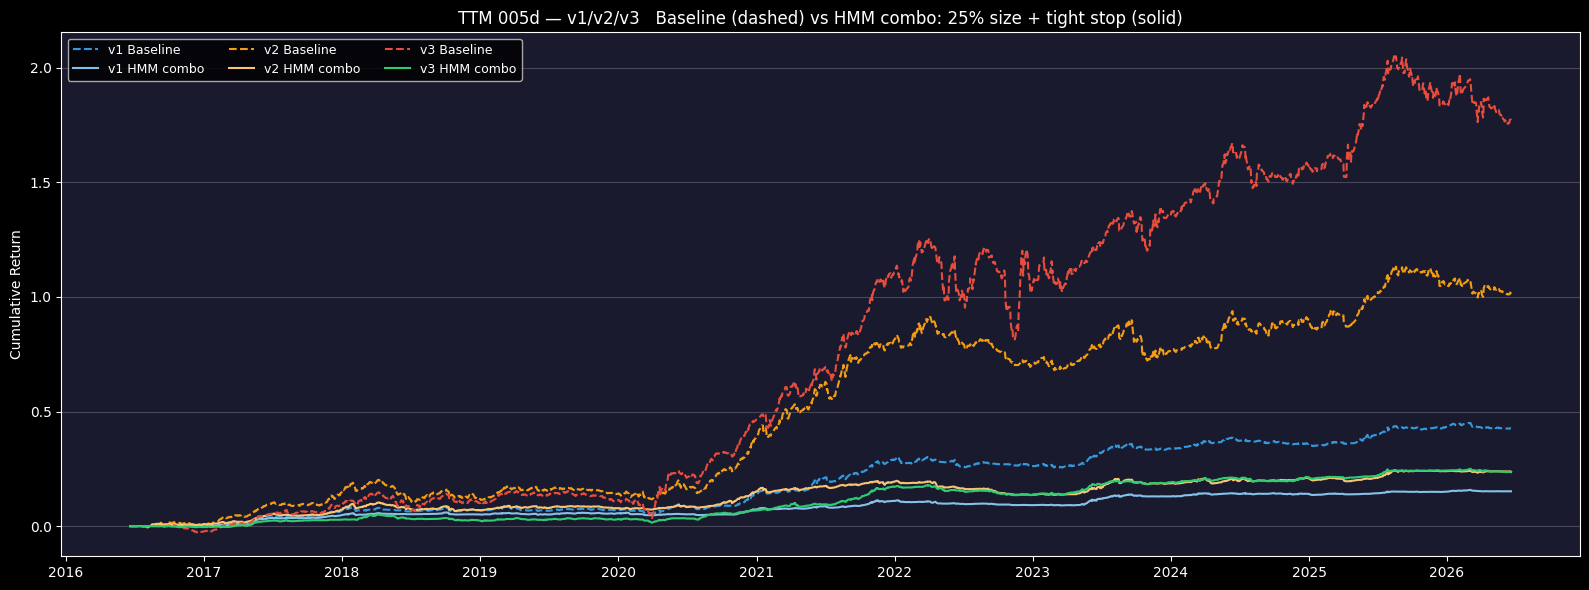

In [95]:
COLORS = {
    ('v1', 'base'): '#3498db', ('v1', 'hmm'): '#85c1e9',
    ('v2', 'base'): '#f39c12', ('v2', 'hmm'): '#f8c471',
    ('v3', 'base'): '#e74c3c', ('v3', 'hmm'): '#2ecc71',
}

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_facecolor('#1a1a2e')
for ver in ['v1', 'v2', 'v3']:
    for kind, ls in [('base', '--'), ('hmm', '-')]:
        pf  = portfolios[(ver, kind)]
        cum = pf.cumulative_returns().mean(axis=1)
        lbl = f'{ver} {"Baseline" if kind=="base" else "HMM combo"}'
        ax.plot(cum.index, cum.values, label=lbl,
                color=COLORS[(ver, kind)], lw=1.5, linestyle=ls)
ax.set_title('TTM 005d — v1/v2/v3   Baseline (dashed) vs HMM combo: 25% size + tight stop (solid)')
ax.set_ylabel('Cumulative Return')
ax.legend(ncol=3, fontsize=9); ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


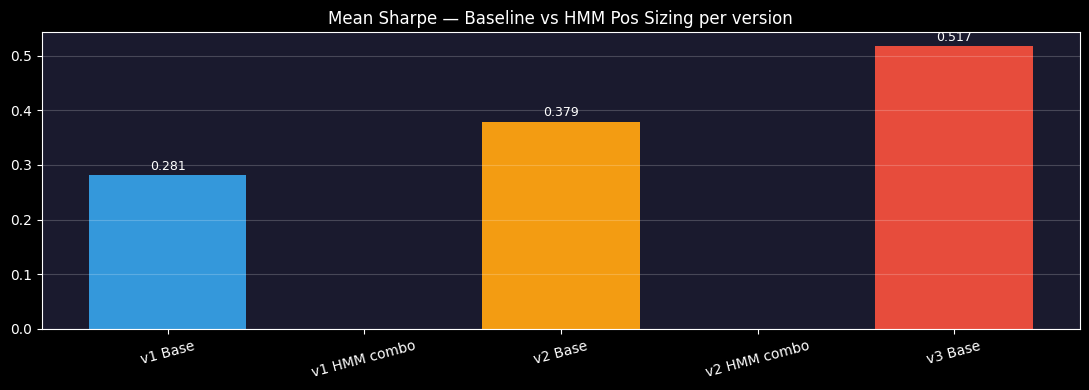

In [96]:
vers   = ['v1', 'v2', 'v3']
labels  = [f'{v} {"Base" if k=="base" else "HMM combo"}' for v in vers for k in ['base','hmm']]
sharpes = [portfolios[(v, k)].sharpe_ratio().mean() for v in vers for k in ['base','hmm']]
colors  = [COLORS[(v, k)] for v in vers for k in ['base','hmm']]

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_facecolor('#1a1a2e')
bars = ax.bar(labels, sharpes, color=colors, edgecolor='none')
ax.axhline(0, color='white', lw=0.5, ls='--')
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='white')
ax.set_title('Mean Sharpe — Baseline vs HMM Pos Sizing per version')
ax.tick_params(axis='x', rotation=15); ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


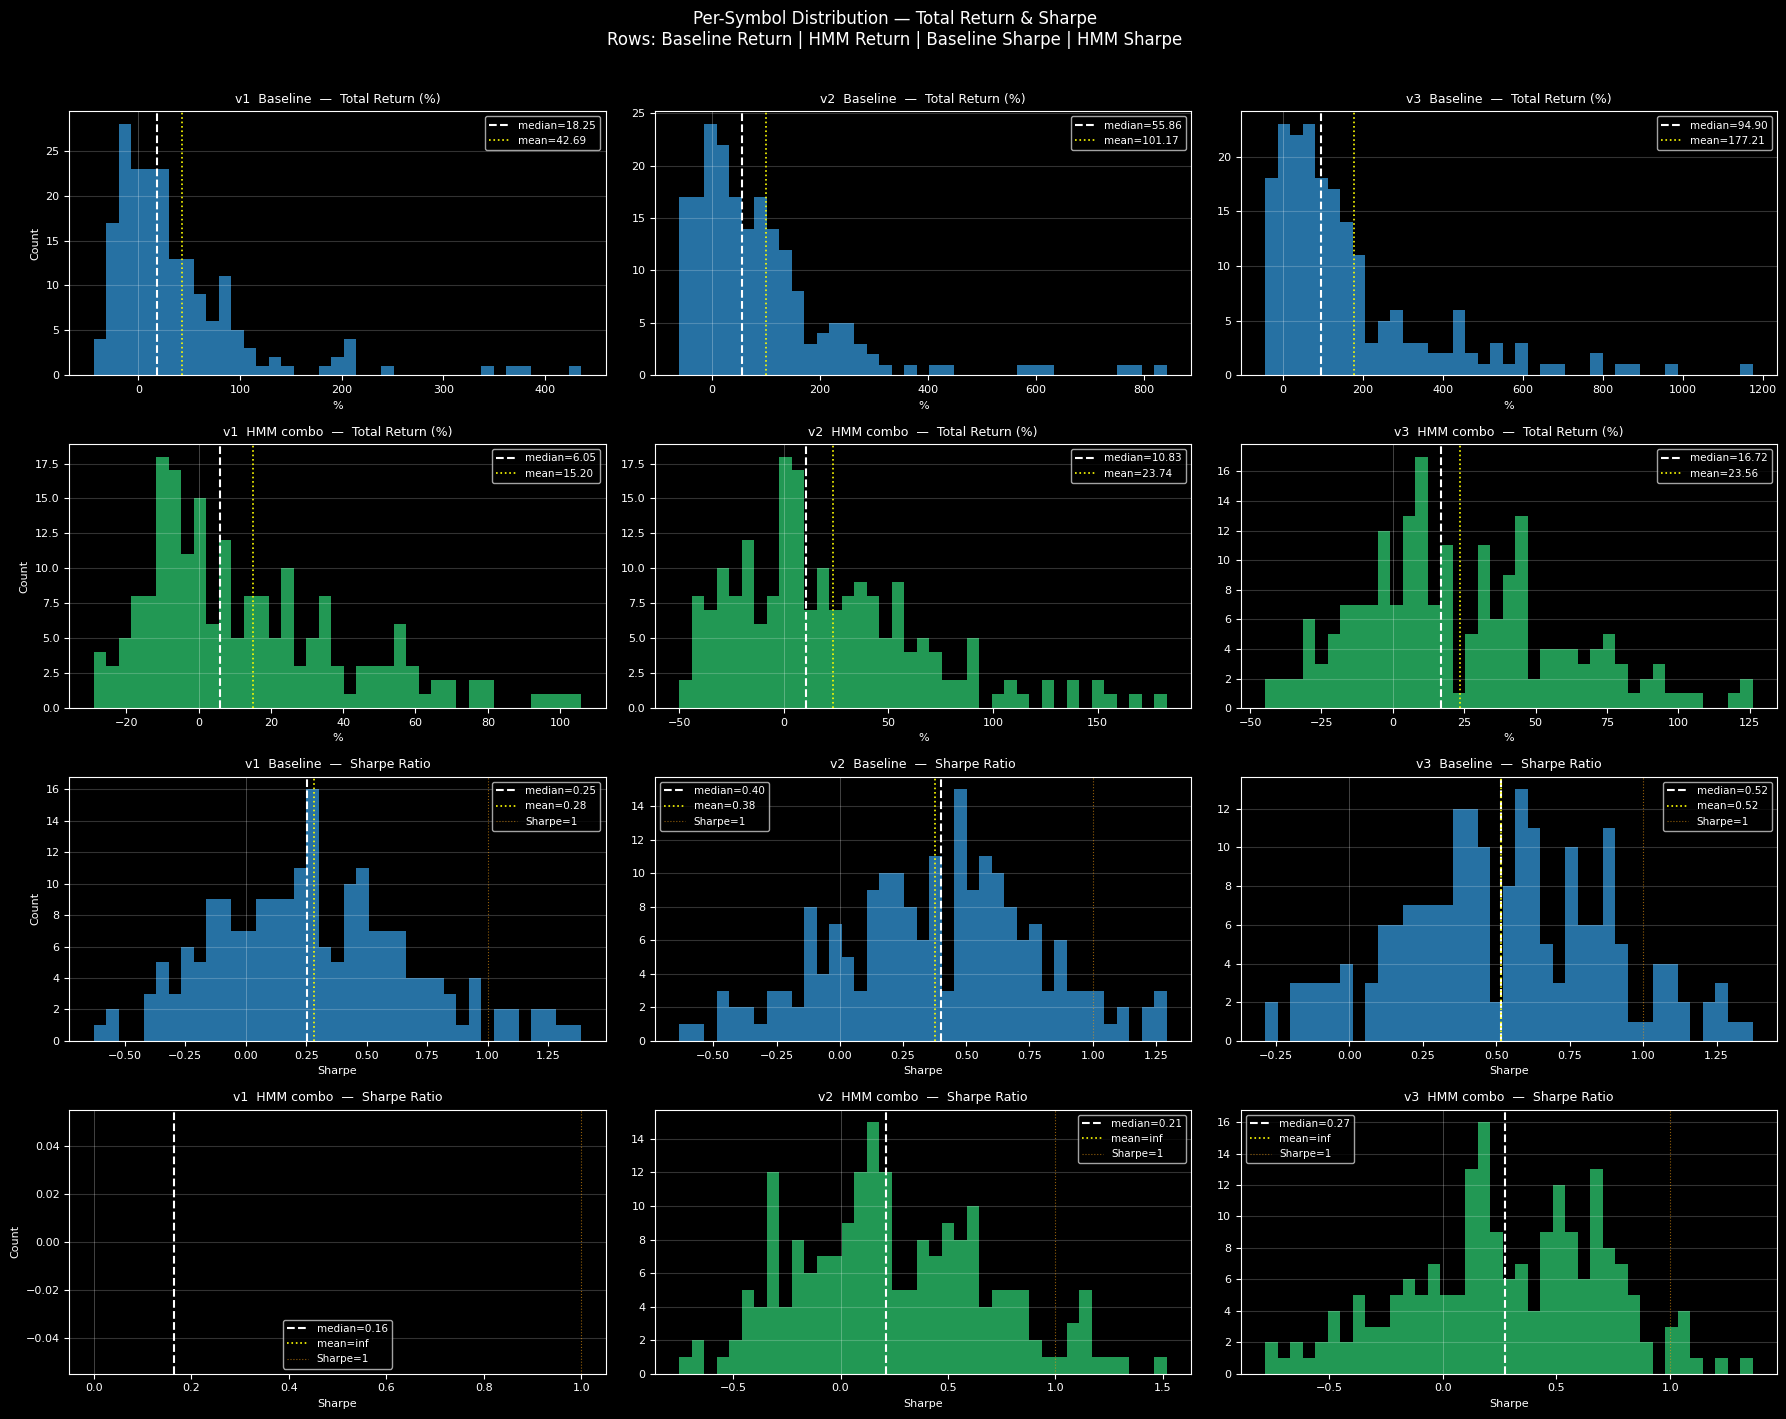

In [97]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Per-Symbol Distribution — Total Return & Sharpe\n'
             'Rows: Baseline Return | HMM Return | Baseline Sharpe | HMM Sharpe',
             fontsize=12, y=1.01)

VERS  = ['v1', 'v2', 'v3']
BINS  = 40
PALETTE = {'base': '#3498db', 'hmm': '#2ecc71'}
LABELS  = {'base': 'Baseline', 'hmm': 'HMM combo'}

row_cfg = [
    ('base', 'total_return', 'Total Return (%)',  True),
    ('hmm',  'total_return', 'Total Return (%)',  True),
    ('base', 'sharpe_ratio', 'Sharpe Ratio',      False),
    ('hmm',  'sharpe_ratio', 'Sharpe Ratio',      False),
]

for row, (kind, metric, ylabel, is_pct) in enumerate(row_cfg):
    for col, ver in enumerate(VERS):
        ax  = axes[row, col]
        pf  = portfolios[(ver, kind)]
        val = getattr(pf, metric)()
        if is_pct:
            val = val * 100
        lo, hi = val.quantile(0.01), val.quantile(0.99)
        bins   = np.linspace(lo, hi, BINS)
        color  = PALETTE[kind]

        ax.hist(val, bins=bins, color=color, alpha=0.75, edgecolor='none')
        ax.axvline(val.median(), color='white', lw=1.5, ls='--', label=f'median={val.median():.2f}')
        ax.axvline(val.mean(),   color='yellow', lw=1.2, ls=':',  label=f'mean={val.mean():.2f}')
        ax.axvline(0, color='white', lw=0.6, alpha=0.3)
        if not is_pct:
            ax.axvline(1, color='#f39c12', lw=0.8, ls=':', alpha=0.6, label='Sharpe=1')

        ax.set_title(f'{ver}  {LABELS[kind]}  —  {ylabel}', fontsize=9)
        ax.set_xlabel('%' if is_pct else 'Sharpe', fontsize=8)
        if col == 0:
            ax.set_ylabel('Count', fontsize=8)
        ax.legend(fontsize=7.5)
        ax.yaxis.grid(True, alpha=0.2)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()
